Mounted at /content/drive

🚀 Training XTM_2023...
Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 92s 287ms/step - loss: 1.3113 - xtm_0_loss: 0.0344 - xtm_10_loss: 0.0219 - xtm_11_loss: 0.0404 - xtm_12_loss: 0.0255 - xtm_13_loss: 0.0424 - xtm_14_loss: 0.0225 - xtm_15_loss: 0.0161 - xtm_16_loss: 0.0170 - xtm_17_loss: 0.0247 - xtm_18_loss: 0.0198 - xtm_19_loss: 0.0159 - xtm_1_loss: 0.0250 - xtm_20_loss: 0.0279 - xtm_21_loss: 0.0224 - xtm_22_loss: 0.0251 - xtm_23_loss: 0.0191 - xtm_24_loss: 0.0275 - xtm_25_loss: 0.0169 - xtm_26_loss: 0.0239 - xtm_27_loss: 0.0253 - xtm_28_loss: 0.0150 - xtm_29_loss: 0.0229 - xtm_2_loss: 0.0273 - xtm_30_loss: 0.0198 - xtm_31_loss: 0.0234 - xtm_32_loss: 0.0223 - xtm_33_loss: 0.0267 - xtm_34_loss: 0.0192 - xtm_35_loss: 0.0137 - xtm_36_loss: 0.0174 - xtm_37_loss: 0.0221 - xtm_38_loss: 0.0216 - xtm_39_loss: 0.0252 - xtm_3_loss: 0.0235 - xtm_40_loss: 0.0222 - xtm_41_loss: 0.0301 - xtm_42_loss: 0.0294 - xtm_43_loss: 0.0321 - xtm_44_loss: 0.0245 - xtm_45_loss: 0.0339 - xt

✅ Mamba_2027_v4 Final RMSE: 1.0412

                   V4 PERFORMANCE RESULTS                   
XTM_2023                       | RMSE: 0.7150
GAT_XTM_2025_v4                | RMSE: 0.8364
Mamba_2027_v4                  | RMSE: 1.0412


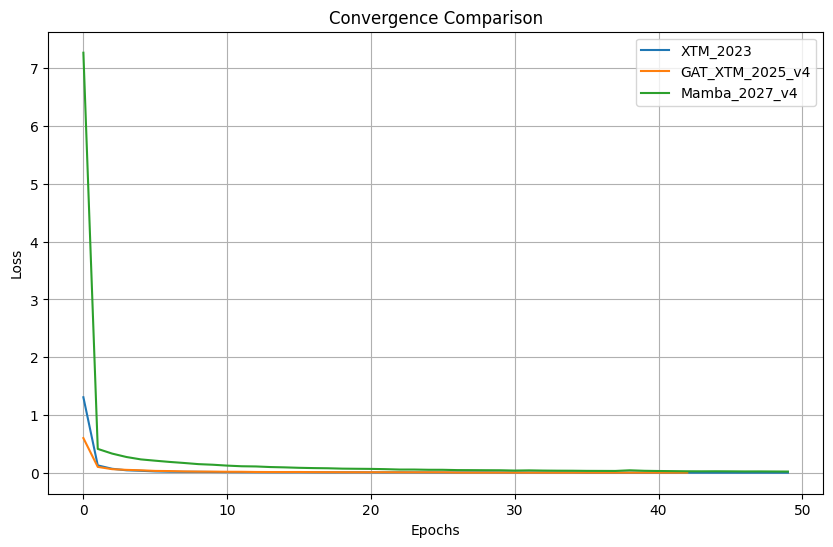

In [ ]:
098# --- 1. IMPORTS ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, callbacks
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive

# --- 2. MOUNT DRIVE & SETUP ---
drive.mount('/content/drive')
root_path = "/content/drive/MyDrive/FDI_Project"
if not os.path.exists(root_path): os.makedirs(root_path)
os.chdir(root_path)

# --- 3. DATA ENGINE ---
class DataEngine:
    def __init__(self, data_path, lookback=48):
        self.lookback = lookback
        df = pd.read_csv(data_path)
        self.raw = df.iloc[:, 1:].astype(float).to_numpy()
        self.scaler = MinMaxScaler().fit(self.raw)
        self.scaled = self.scaler.transform(self.raw)

        split = int(len(self.scaled) * 0.8)
        self.train_data = self.scaled[:split]
        self.test_data = self.scaled[split:]

    def generator(self, data, batch_size=64):
        while True:
            rows = np.random.randint(self.lookback, len(data), size=batch_size)
            samples = np.array([data[r-self.lookback:r] for r in rows])
            targets = np.array([data[r] for r in rows])
            yield (samples, tuple(targets[:, i] for i in range(54)))

# --- 4. MODEL FACTORY ---
class ModelFactory:
    @staticmethod
    def build_xtm_2023(input_shape=(48, 54)):
        inputs = keras.Input(shape=input_shape)
        x = layers.MultiHeadAttention(num_heads=6, key_dim=9)(inputs, inputs)
        x = layers.LayerNormalization()(x + inputs)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.LSTM(128)(x)
        x = layers.Dense(128, activation='relu')(x)
        outputs = [layers.Dense(1, name=f"xtm_{i}")(x) for i in range(54)]
        model = keras.Model(inputs, outputs, name="XTM_2023")
        model.compile(optimizer='adam', loss='mse')
        return model


    @staticmethod
    def build_gat_xtm_2025_v4(input_shape=(48, 54)):
        inputs = keras.Input(shape=input_shape)

        spatial = layers.Dense(128, activation='swish')(inputs)
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=16)(spatial, spatial)
        spatial = layers.Add()([spatial, attn])

        temporal_res = layers.Dense(128)(inputs)

        x = layers.Add()([spatial, temporal_res])
        x = layers.LayerNormalization()(x)

        x = layers.Bidirectional(layers.LSTM(128))(x)
        x = layers.Dense(256, activation='swish')(x)

        outputs = [layers.Dense(1, name=f"gat_{i}")(x) for i in range(54)]
        model = keras.Model(inputs, outputs, name="GAT_XTM_2025_v4")
        model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
        return model


    def build_mamba_2027_v4(input_shape=(48, 54)):
        inputs = keras.Input(shape=input_shape)

        x = layers.Dense(128)(inputs)

        c1 = layers.Conv1D(128, 3, padding='same', activation='swish')(x)
        c2 = layers.Conv1D(128, 3, padding='same', dilation_rate=2, activation='sigmoid')(x)
        x_gated = layers.Multiply()([c1, c2])

        x = layers.Add()([x, x_gated])
        x = layers.LayerNormalization()(x)

        x = la@staticmethodyers.Flatten()(x)
        x = layers.Dense(256, activation='swish')(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(128, activation='swish')(x)

        outputs = [layers.Dense(1, name=f"mamba_{i}")(x) for i in range(54)]
        model = keras.Model(inputs, outputs, name="Mamba_2027_v4")
        model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
        return model

# --- 5. INITIALIZATION ---
DATA_FILE = "/content/drive/MyDrive/hourly_dataset (2).csv"
de = DataEngine(DATA_FILE)

output_sig = (
    tf.TensorSpec(shape=(None, 48, 54), dtype=tf.float32),
    tuple(tf.TensorSpec(shape=(None,), dtype=tf.float32) for _ in range(54))
)

train_ds = tf.data.Dataset.from_generator(
    lambda: de.generator(de.train_data),
    output_signature=output_sig
).prefetch(tf.data.AUTOTUNE)

# --- 6. TRAINING ---
models_to_run = [
    ModelFactory.build_xtm_2023(),
    ModelFactory.build_gat_xtm_2025_v4(),
    ModelFactory.build_mamba_2027_v4()
]

histories, final_results = {}, []

for m in models_to_run:
    print(f"\n🚀 Training {m.name}...")

    cb = [
        callbacks.EarlyStopping(monitor='loss', patience=6, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='loss', factor=0.2, patience=3)
    ]

    h = m.fit(train_ds, steps_per_epoch=200, epochs=50, callbacks=cb, verbose=1)
    histories[m.name] = h

    # --- Evaluation ---
    test_idx = np.arange(0, len(de.test_data) - 48)
    test_samples = np.array([de.test_data[i:i+48] for i in test_idx])
    test_real = np.array([de.test_data[i+48] for i in test_idx])

    raw_preds = m.predict(test_samples, batch_size=256, verbose=0)
    stacked_preds = np.stack(raw_preds, axis=1).squeeze()

    real_inv = de.scaler.inverse_transform(test_real)
    pred_inv = de.scaler.inverse_transform(stacked_preds)

    rmse = np.sqrt(np.mean((real_inv - pred_inv) ** 2))
    final_results.append({"Model": m.name, "RMSE": rmse})

    print(f"✅ {m.name} Final RMSE: {rmse:.4f}")

# --- 7. SUMMARY ---

print(f"{'V4 PERFORMANCE RESULTS':^60}")

for r in final_results:
    print(f"{r['Model']:<30} | RMSE: {r['RMSE']:.4f}")
print("="*60)

# --- 8. 📊 CONVERGENCE PLOT ---
plt.figure(figsize=(10,6))

for name, hist in histories.items():
    plt.plot(hist.history['loss'], label=name)

plt.title("Convergence Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()
